# PBL Fase 6 — "Ir Além" (Opção 2)
## Transfer Learning + Fine Tuning e Segmentação

**Autor:** Bruno — RM567213  
**Grupo:** FlexMedia FIAP  
**Dataset base:** 80 imagens (classes: `faca` e `celular`) rotuladas e estruturadas pela integrante Yasmin (Entrega 1 — YOLOv8n customizado).

---

### Objetivo
Este notebook implementa e avalia as **duas abordagens** da seção 3.2 do enunciado:

1. **Abordagem 1 — Transfer Learning + Fine Tuning:** comparamos uma CNN treinada do zero com a rede **MobileNetV2** pré-treinada na ImageNet e ajustada (fine tuning) ao nosso dataset.  
   *Hipótese:* uma grande rede pré-treinada performa melhor que uma CNN do zero em um dataset pequeno?

2. **Abordagem 2 — Segmentação + Classificação:** usamos uma rede de segmentação (**YOLOv8n-seg**) para gerar máscaras dos objetos, recortamos o fundo, e reavaliamos a classificação no MobileNetV2.  
   *Hipótese:* pré-segmentar o objeto de interesse facilita a classificação?

### Justificativas técnicas
- **MobileNetV2** foi escolhida por ser leve, eficiente em CPU/GPU pequeno (ideal para Colab gratuito) e ter performance competitiva. Ela tem `~3.4M` parâmetros contra `~138M` da VGG16 — mais adequado ao nosso dataset de 80 imagens.
- **Camada de congelamento:** inicialmente congelamos toda a base convolucional. No fine tuning, descongelamos a partir do bloco `block_13_expand` (últimas ~30 camadas) para adaptar features de alto nível sem destruir features genéricas.
- **YOLOv8n-seg** foi escolhida como rede de segmentação porque já está pré-treinada em COCO (classes `knife` id=43 e `cell phone` id=67 existem), evitando rotulação manual de máscaras. A biblioteca `ultralytics` retorna diretamente as máscaras binárias por instância.

## 1. Setup — Upload do dataset e instalação de dependências

**Fluxo sem Google Drive:** fazer upload do arquivo `fiap_dataset.zip` (gerado localmente) diretamente no Colab. Execute a célula abaixo e selecione o arquivo quando pedido.

In [1]:
# Upload fiap_dataset.zip e extrai em /content/fiap.
# Trata zip com separador Windows (\) caso tenha sido gerado no PowerShell.
from google.colab import files
import zipfile, os, shutil, glob

if os.path.exists('/content/fiap'):
    shutil.rmtree('/content/fiap')

uploaded = files.upload()  # selecionar fiap_dataset.zip
zip_name = list(uploaded.keys())[0]
os.makedirs('/content/fiap', exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/fiap')

# Fix: se zip trouxe arquivos com '\' literal no nome (PowerShell bug),
# move-os para subpastas reais.
for fname in list(os.listdir('/content/fiap')):
    src = os.path.join('/content/fiap', fname)
    if os.path.isfile(src) and '\\' in fname:
        rel = fname.replace('\\', '/')
        dst = os.path.join('/content/fiap', rel)
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.move(src, dst)

print('Train imgs:', len(glob.glob('/content/fiap/train/images/*')))
print('Valid imgs:', len(glob.glob('/content/fiap/valid/images/*')))
print('Test imgs:',  len(glob.glob('/content/fiap/test/images/*')))

Saving fiap_dataset.zip to fiap_dataset.zip
Train imgs: 64
Valid imgs: 8
Test imgs: 8


In [2]:
# ultralytics: YOLO + segmentacao | tensorflow: TL + CNN
!pip install -q ultralytics tensorflow scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.9 MB/s eta 0:00:00


In [3]:
import os, glob, shutil, time, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

from ultralytics import YOLO

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print('TF:', tf.__version__, '| GPU:', tf.config.list_physical_devices('GPU'))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
TF: 2.19.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset — carregamento a partir dos nomes de arquivo

A Entrega 1 deixou o dataset estruturado em `train/`, `valid/`, `test/` no Drive. Como o enunciado da Entrega 2 pede **classificação** (não detecção), precisamos de um rótulo único por imagem. Usamos o **prefixo do nome do arquivo** (`faca*` → classe `faca`, `celula*` → classe `celular`) como ground truth, que é determinístico e confiável.

In [4]:
DATASET_ROOT = '/content/fiap'
IMG_SIZE = (224, 224)
BATCH = 8
CLASSES = ['celular', 'faca']  # ordem alfabetica
CLASS_IDX = {c: i for i, c in enumerate(CLASSES)}
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

def label_from_filename(path: str) -> int:
    name = os.path.basename(path).lower()
    if name.startswith('faca'):
        return CLASS_IDX['faca']
    if name.startswith('celula'):
        return CLASS_IDX['celular']
    raise ValueError(f'Arquivo sem prefixo conhecido: {name}')

def is_valid_image(path: str) -> bool:
    # Valida usando OpenCV (imread retorna None se formato invalido)
    try:
        img = cv2.imread(path)
        return img is not None
    except Exception:
        return False

def list_split(split: str):
    img_dir = os.path.join(DATASET_ROOT, split, 'images')
    candidates = sorted([p for p in glob.glob(os.path.join(img_dir, '*'))
                         if os.path.splitext(p)[1].lower() in IMG_EXTS])
    paths = [p for p in candidates if is_valid_image(p)]
    skipped = len(candidates) - len(paths)
    if skipped:
        print(f'[{split}] pulados {skipped} arquivos invalidos')
    labels = [label_from_filename(p) for p in paths]
    return paths, labels

train_paths, train_labels = list_split('train')
valid_paths, valid_labels = list_split('valid')
test_paths,  test_labels  = list_split('test')

print(f'Train: {len(train_paths)}  Valid: {len(valid_paths)}  Test: {len(test_paths)}')
print('Distribuicao train:', {CLASSES[i]: train_labels.count(i) for i in range(len(CLASSES))})

Train: 64  Valid: 8  Test: 8
Distribuicao train: {'celular': 32, 'faca': 32}


In [5]:
# Pre-carrega imagens com OpenCV (mais robusto que tf.io.decode_image para
# formatos diversos). Dataset pequeno (80 imgs), cabe na memoria.

def load_images(paths):
    arr = np.zeros((len(paths), *IMG_SIZE, 3), dtype=np.float32)
    for i, p in enumerate(paths):
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        arr[i] = img.astype(np.float32)
    return arr

X_train = load_images(train_paths)
X_valid = load_images(valid_paths)
X_test  = load_images(test_paths)
y_train = np.array(train_labels, dtype=np.int32)
y_valid = np.array(valid_labels, dtype=np.int32)
y_test  = np.array(test_labels,  dtype=np.int32)
print('Shapes:', X_train.shape, X_valid.shape, X_test.shape)

def augment_tf(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    return img, label

def make_ds(X, y, augment=False, shuffle=False, preprocess=None):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(len(X), seed=SEED)
    if augment:
        ds = ds.map(augment_tf, num_parallel_calls=tf.data.AUTOTUNE)
    if preprocess is not None:
        ds = ds.map(lambda x, yy: (preprocess(x), yy), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

cnn_norm = lambda x: x / 255.0
train_cnn = make_ds(X_train, y_train, augment=True, shuffle=True, preprocess=cnn_norm)
valid_cnn = make_ds(X_valid, y_valid, preprocess=cnn_norm)
test_cnn  = make_ds(X_test,  y_test,  preprocess=cnn_norm)

train_mn = make_ds(X_train, y_train, augment=True, shuffle=True, preprocess=preprocess_input)
valid_mn = make_ds(X_valid, y_valid, preprocess=preprocess_input)
test_mn  = make_ds(X_test,  y_test,  preprocess=preprocess_input)

print('Datasets prontos.')

Shapes: (64, 224, 224, 3) (8, 224, 224, 3) (8, 224, 224, 3)
Datasets prontos.


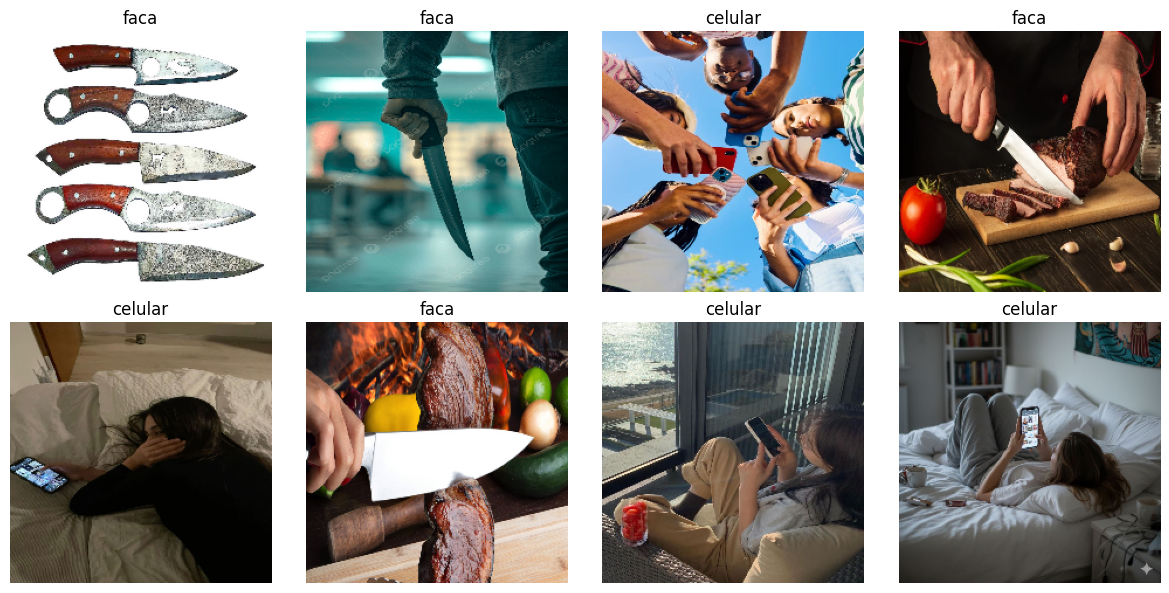

In [6]:
# Visualizar 1 batch para conferir rotulacao
idx = np.random.RandomState(SEED).choice(len(X_train), 8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train[i].astype('uint8'))
    ax.set_title(CLASSES[y_train[i]])
    ax.axis('off')
plt.tight_layout(); plt.show()

## 3. Abordagem 1a — CNN do zero (baseline)
Arquitetura pequena (3 blocos Conv-Pool + Dense) para termos um baseline de comparação.

In [7]:
def build_cnn_scratch():
    m = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(len(CLASSES), activation='softmax'),
    ], name='cnn_scratch')
    m.compile(optimizer=optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

cnn = build_cnn_scratch()
cnn.summary()

es = callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy')
t0 = time.time()
hist_cnn = cnn.fit(train_cnn, validation_data=valid_cnn, epochs=40, callbacks=[es], verbose=2)
cnn_train_time = time.time() - t0
print(f'Tempo treino CNN do zero: {cnn_train_time:.1f}s')

Model: "cnn_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,634 (397.01 KB)

 Trainable params: 101,634 (397.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
8/8 - 13s - 2s/step - accuracy: 0.4375 - loss: 0.6983 - val_accuracy: 0.5000 - val_loss: 0.6914
Epoch 2/40
8/8 - 0s - 22ms/step - accuracy: 0.4531 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.6914
Epoch 3/40
8/8 - 0s - 21ms/step - accuracy: 0.5156 - loss: 0.6907 - val_accuracy: 0.5000 - val_loss: 0.6916
Epoch 4/40
8/8 - 0s - 22ms/step - accuracy: 0.5625 - loss: 0.6911 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 5/40
8/8 - 0s - 22ms/step - accuracy: 0.5156 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.7116
Epoch 6/40
8/8 - 0s - 26ms/step - accuracy: 0.6094 - loss: 0.6911 - val_accuracy: 0.3750 - val_loss: 0.6964
Epoch 7/40
8/8 - 0s - 26ms/step - accuracy: 0.4844 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss: 0.6947
Epoch 8/40
8/8 - 0s - 28ms/step - accuracy: 0.5312 - loss: 0.6884 - val_accuracy: 0.5000 - val_loss: 0.6904
Epoch 9/40
8/8 - 0s - 25ms/step - accuracy: 0.5000 - loss: 0.6790 - val_accuracy: 0.5000 - val_loss: 0.6903
Tempo treino CNN do zero: 14.

In [8]:
t0 = time.time()
cnn_eval = cnn.evaluate(test_cnn, verbose=0)
cnn_infer_time = (time.time() - t0) / len(test_paths)
cnn_preds = np.argmax(cnn.predict(test_cnn, verbose=0), axis=1)
print(f'CNN do zero — test acc: {cnn_eval[1]:.3f} | inferencia/img: {cnn_infer_time*1000:.1f} ms')
print(classification_report(y_test, cnn_preds, target_names=CLASSES, zero_division=0))

CNN do zero — test acc: 0.500 | inferencia/img: 5.5 ms
              precision    recall  f1-score   support

     celular       0.00      0.00      0.00         4
        faca       0.50      1.00      0.67         4

    accuracy                           0.50         8
   macro avg       0.25      0.50      0.33         8
weighted avg       0.25      0.50      0.33         8



## 4. Abordagem 1b — Transfer Learning com MobileNetV2 + Fine Tuning

**Duas fases:**  
**Fase A (feature extraction):** congela toda a `base` e treina só o topo.  
**Fase B (fine tuning):** descongela a partir de `block_13_expand` e reduz LR em 10×.

In [9]:
def build_mobilenet(trainable_base=False):
    base = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    base.trainable = trainable_base
    inp = layers.Input(shape=(*IMG_SIZE, 3))
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(len(CLASSES), activation='softmax')(x)
    m = models.Model(inp, out, name='mobilenetv2_tl')
    return m, base

mn, base = build_mobilenet(trainable_base=False)
mn.compile(optimizer=optimizers.Adam(1e-3),
           loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mn.summary()

# Fase A: feature extraction
es_a = callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_accuracy')
t0 = time.time()
hist_a = mn.fit(train_mn, validation_data=valid_mn, epochs=25, callbacks=[es_a], verbose=2)
mn_phaseA_time = time.time() - t0
print(f'MobileNetV2 Fase A — tempo: {mn_phaseA_time:.1f}s')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_tl"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/25
8/8 - 21s - 3s/step - accuracy: 0.7031 - loss: 0.5988 - val_accuracy: 1.0000 - val_loss: 0.2420
Epoch 2/25
8/8 - 0s - 23ms/step - accuracy: 0.7969 - loss: 0.3887 - val_accuracy: 0.8750 - val_loss: 0.1928
Epoch 3/25
8/8 - 0s - 24ms/step - accuracy: 0.9688 - loss: 0.1807 - val_accuracy: 0.8750 - val_loss: 0.1509
Epoch 4/25
8/8 - 0s - 25ms/step - accuracy: 0.9531 - loss: 0.1639 - val_accuracy: 0.8750 - val_loss: 0.1398
Epoch 5/25
8/8 - 0s - 25ms/step - accuracy: 0.9375 - loss: 0.1589 - val_accuracy: 0.8750 - val_loss: 0.1369
Epoch 6/25
8/8 - 0s - 24ms/step - accuracy: 1.0000 - loss: 0.0669 - val_accuracy: 1.0000 - val_loss: 0.1188
Epoch 7/25
8/8 - 0s - 30ms/step - accuracy: 0.9844 - loss: 0.0823 - val_accuracy: 1.0000 - val_loss: 0.1125
MobileNetV2 Fase A — tempo: 22.2s


In [10]:
# Fase B: fine tuning a partir de block_13_expand
base.trainable = True
freeze_until = None
for i, layer in enumerate(base.layers):
    if layer.name == 'block_13_expand':
        freeze_until = i
        break
for layer in base.layers[:freeze_until]:
    layer.trainable = False
trainable = sum(1 for l in base.layers if l.trainable)
print(f'Descongeladas: {trainable}/{len(base.layers)} camadas (de {base.layers[freeze_until].name} em diante)')

mn.compile(optimizer=optimizers.Adam(1e-4),
           loss='sparse_categorical_crossentropy', metrics=['accuracy'])
es_b = callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy')
t0 = time.time()
hist_b = mn.fit(train_mn, validation_data=valid_mn, epochs=25, callbacks=[es_b], verbose=2)
mn_phaseB_time = time.time() - t0
mn_train_time = mn_phaseA_time + mn_phaseB_time
print(f'MobileNetV2 Fase B — tempo: {mn_phaseB_time:.1f}s | total: {mn_train_time:.1f}s')

Descongeladas: 38/154 camadas (de block_13_expand em diante)
Epoch 1/25
8/8 - 23s - 3s/step - accuracy: 0.7344 - loss: 0.4716 - val_accuracy: 1.0000 - val_loss: 0.1258
Epoch 2/25
8/8 - 0s - 30ms/step - accuracy: 0.9375 - loss: 0.1962 - val_accuracy: 1.0000 - val_loss: 0.0934
Epoch 3/25
8/8 - 0s - 26ms/step - accuracy: 1.0000 - loss: 0.0582 - val_accuracy: 1.0000 - val_loss: 0.0905
Epoch 4/25
8/8 - 0s - 25ms/step - accuracy: 0.9688 - loss: 0.1171 - val_accuracy: 1.0000 - val_loss: 0.0931
Epoch 5/25
8/8 - 0s - 25ms/step - accuracy: 1.0000 - loss: 0.0214 - val_accuracy: 1.0000 - val_loss: 0.0982
Epoch 6/25
8/8 - 0s - 24ms/step - accuracy: 0.9219 - loss: 0.1455 - val_accuracy: 1.0000 - val_loss: 0.1007
Epoch 7/25
8/8 - 0s - 25ms/step - accuracy: 1.0000 - loss: 0.0179 - val_accuracy: 1.0000 - val_loss: 0.1053
Epoch 8/25
8/8 - 0s - 24ms/step - accuracy: 0.9531 - loss: 0.0975 - val_accuracy: 1.0000 - val_loss: 0.1089
Epoch 9/25
8/8 - 0s - 29ms/step - accuracy: 0.9844 - loss: 0.0533 - val_accu

In [11]:
t0 = time.time()
mn_eval = mn.evaluate(test_mn, verbose=0)
mn_infer_time = (time.time() - t0) / len(test_paths)
mn_preds = np.argmax(mn.predict(test_mn, verbose=0), axis=1)
print(f'MobileNetV2 TL — test acc: {mn_eval[1]:.3f} | inferencia/img: {mn_infer_time*1000:.1f} ms')
print(classification_report(y_test, mn_preds, target_names=CLASSES, zero_division=0))

MobileNetV2 TL — test acc: 1.000 | inferencia/img: 10.9 ms
              precision    recall  f1-score   support

     celular       1.00      1.00      1.00         4
        faca       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



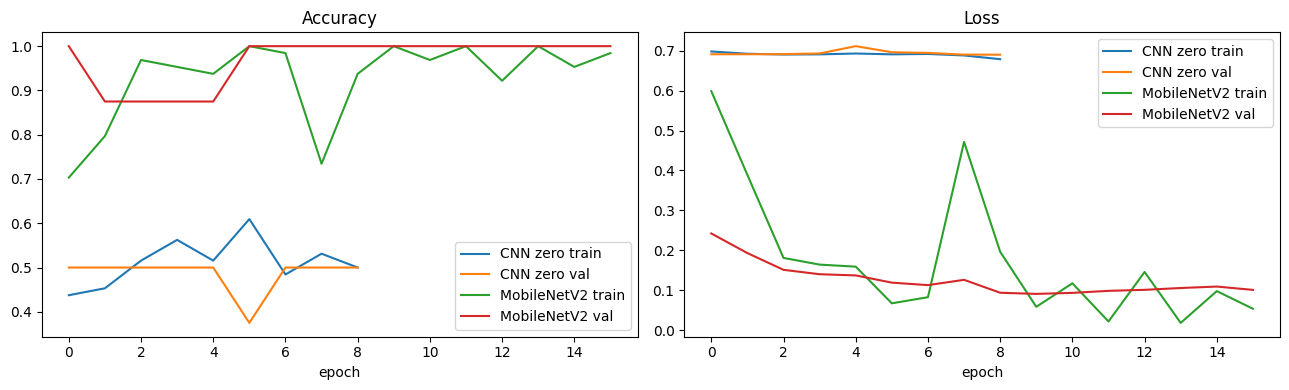

In [12]:
# Curvas de treino - comparacao
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_cnn.history['accuracy'], label='CNN zero train')
axes[0].plot(hist_cnn.history['val_accuracy'], label='CNN zero val')
axes[0].plot(hist_a.history['accuracy'] + hist_b.history['accuracy'], label='MobileNetV2 train')
axes[0].plot(hist_a.history['val_accuracy'] + hist_b.history['val_accuracy'], label='MobileNetV2 val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(hist_cnn.history['loss'], label='CNN zero train')
axes[1].plot(hist_cnn.history['val_loss'], label='CNN zero val')
axes[1].plot(hist_a.history['loss'] + hist_b.history['loss'], label='MobileNetV2 train')
axes[1].plot(hist_a.history['val_loss'] + hist_b.history['val_loss'], label='MobileNetV2 val')
axes[1].set_title('Loss'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Abordagem 2 — Segmentação + Classificação

Usamos **YOLOv8n-seg** (pré-treinada em COCO) para gerar máscaras binárias dos objetos. As classes COCO `knife` (id=43) e `cell phone` (id=67) cobrem nossas duas classes. Aplicamos a máscara à imagem original pintando o fundo de preto e reclassificamos com o MobileNetV2 já fine-tunado.

In [13]:
seg_model = YOLO('yolov8n-seg.pt')  # baixa automaticamente
COCO_TARGET = {43, 67}  # knife, cell phone

SEG_OUT = '/content/seg_out'
for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(SEG_OUT, split), exist_ok=True)

def segment_and_save(img_path: str, out_path: str):
    """Roda YOLO-seg, combina mascaras dos alvos e salva imagem com fundo preto.
    Retorna True se achou pelo menos um objeto, False caso contrario (usa imagem original)."""
    img = cv2.imread(img_path)
    if img is None:
        return False
    h, w = img.shape[:2]
    res = seg_model.predict(img, conf=0.25, verbose=False)[0]
    if res.masks is None or len(res.masks) == 0:
        cv2.imwrite(out_path, img)
        return False
    cls_ids = res.boxes.cls.cpu().numpy().astype(int)
    masks = res.masks.data.cpu().numpy()  # [N, h', w']
    combined = np.zeros((h, w), dtype=np.uint8)
    found = False
    for m, c in zip(masks, cls_ids):
        m_up = cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
        if c in COCO_TARGET:
            combined = np.maximum(combined, m_up)
            found = True
    if not found:
        # fallback: usa mascara de maior area entre todas (mesmo fora COCO_TARGET)
        areas = [(cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)).sum() for m in masks]
        best = int(np.argmax(areas))
        combined = cv2.resize(masks[best].astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
    mask3 = np.stack([combined] * 3, axis=-1)
    cropped = img * mask3  # background -> 0 (preto)
    cv2.imwrite(out_path, cropped)
    return found

# Gera versao segmentada para todos os splits
seg_stats = {}
for split, paths in [('train', train_paths), ('valid', valid_paths), ('test', test_paths)]:
    hits = 0
    for p in paths:
        out = os.path.join(SEG_OUT, split, os.path.basename(p))
        if segment_and_save(p, out):
            hits += 1
    seg_stats[split] = (hits, len(paths))
    print(f'{split}: {hits}/{len(paths)} com mascara da classe alvo (demais: fallback)')

train: 34/64 com mascara da classe alvo (demais: fallback)
valid: 7/8 com mascara da classe alvo (demais: fallback)
test: 6/8 com mascara da classe alvo (demais: fallback)


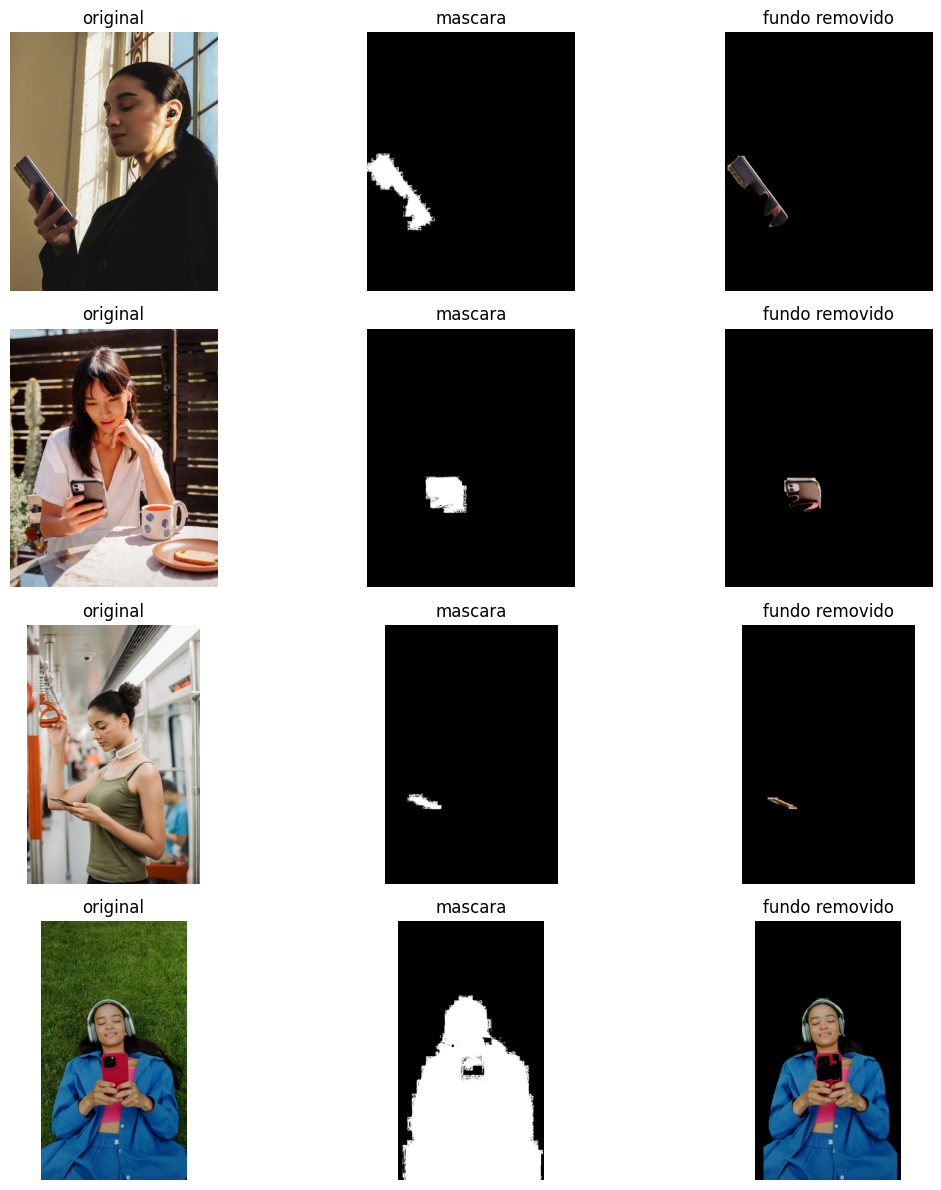

In [14]:
# Visualizacao: original | mascara | recortada
sample = test_paths[:4]
fig, axes = plt.subplots(len(sample), 3, figsize=(12, 3 * len(sample)))
for i, p in enumerate(sample):
    orig = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    seg_path = os.path.join(SEG_OUT, 'test', os.path.basename(p))
    seg = cv2.cvtColor(cv2.imread(seg_path), cv2.COLOR_BGR2RGB)
    mask = cv2.cvtColor((seg.sum(axis=-1) > 0).astype(np.uint8) * 255, cv2.COLOR_GRAY2RGB)
    axes[i, 0].imshow(orig); axes[i, 0].set_title('original'); axes[i, 0].axis('off')
    axes[i, 1].imshow(mask); axes[i, 1].set_title('mascara'); axes[i, 1].axis('off')
    axes[i, 2].imshow(seg);  axes[i, 2].set_title('fundo removido'); axes[i, 2].axis('off')
plt.tight_layout(); plt.show()

In [15]:
# Carrega imagens segmentadas e reclassifica com MobileNetV2 fine-tunado
def seg_paths(split, orig_paths):
    return [os.path.join(SEG_OUT, split, os.path.basename(p)) for p in orig_paths]

test_seg_paths  = seg_paths('test',  test_paths)
X_test_seg  = load_images(test_seg_paths)
test_seg_ds = make_ds(X_test_seg, y_test, preprocess=preprocess_input)

t0 = time.time()
mn_seg_eval = mn.evaluate(test_seg_ds, verbose=0)
mn_seg_infer = (time.time() - t0) / len(test_paths)
mn_seg_preds = np.argmax(mn.predict(test_seg_ds, verbose=0), axis=1)
print(f'MobileNetV2 + segmentacao — test acc: {mn_seg_eval[1]:.3f} | inferencia/img: {mn_seg_infer*1000:.1f} ms (sem contar seg)')
print(classification_report(y_test, mn_seg_preds, target_names=CLASSES, zero_division=0))

MobileNetV2 + segmentacao — test acc: 1.000 | inferencia/img: 10.8 ms (sem contar seg)
              precision    recall  f1-score   support

     celular       1.00      1.00      1.00         4
        faca       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



### 5b. Opcional — re-treinar MobileNetV2 do zero nas imagens segmentadas

O bloco acima mede quão bem o modelo treinado em imagens *originais* generaliza para imagens *segmentadas* (domain shift). Fazemos também um experimento coerente: treinar um **novo** MobileNetV2 diretamente em imagens segmentadas para isolar o efeito da pré-segmentação.

In [16]:
train_seg_paths = seg_paths('train', train_paths)
valid_seg_paths = seg_paths('valid', valid_paths)
X_train_seg = load_images(train_seg_paths)
X_valid_seg = load_images(valid_seg_paths)
train_seg_ds = make_ds(X_train_seg, y_train, augment=True, shuffle=True, preprocess=preprocess_input)
valid_seg_ds = make_ds(X_valid_seg, y_valid, preprocess=preprocess_input)

mn_seg, base_seg = build_mobilenet(trainable_base=False)
mn_seg.compile(optimizer=optimizers.Adam(1e-3),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_seg_a = mn_seg.fit(train_seg_ds, validation_data=valid_seg_ds, epochs=20,
                        callbacks=[callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_accuracy')],
                        verbose=2)

base_seg.trainable = True
for i, l in enumerate(base_seg.layers):
    if l.name == 'block_13_expand':
        cut = i; break
for l in base_seg.layers[:cut]:
    l.trainable = False
mn_seg.compile(optimizer=optimizers.Adam(1e-4),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_seg_b = mn_seg.fit(train_seg_ds, validation_data=valid_seg_ds, epochs=20,
                        callbacks=[callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy')],
                        verbose=2)

mn_seg_retrain_eval = mn_seg.evaluate(test_seg_ds, verbose=0)
mn_seg_retrain_preds = np.argmax(mn_seg.predict(test_seg_ds, verbose=0), axis=1)
print(f'MobileNetV2 RE-treinado em imagens segmentadas — test acc: {mn_seg_retrain_eval[1]:.3f}')
print(classification_report(y_test, mn_seg_retrain_preds, target_names=CLASSES, zero_division=0))

Epoch 1/20
8/8 - 14s - 2s/step - accuracy: 0.4688 - loss: 1.0352 - val_accuracy: 0.6250 - val_loss: 0.6062
Epoch 2/20
8/8 - 0s - 39ms/step - accuracy: 0.5469 - loss: 0.7980 - val_accuracy: 0.7500 - val_loss: 0.4707
Epoch 3/20
8/8 - 0s - 24ms/step - accuracy: 0.7031 - loss: 0.4604 - val_accuracy: 0.7500 - val_loss: 0.3591
Epoch 4/20
8/8 - 0s - 35ms/step - accuracy: 0.8438 - loss: 0.3652 - val_accuracy: 0.8750 - val_loss: 0.3435
Epoch 5/20
8/8 - 0s - 23ms/step - accuracy: 0.8438 - loss: 0.2921 - val_accuracy: 0.8750 - val_loss: 0.3503
Epoch 6/20
8/8 - 0s - 22ms/step - accuracy: 0.8906 - loss: 0.2307 - val_accuracy: 0.7500 - val_loss: 0.2455
Epoch 7/20
8/8 - 0s - 38ms/step - accuracy: 0.9531 - loss: 0.1747 - val_accuracy: 0.8750 - val_loss: 0.2411
Epoch 8/20
8/8 - 0s - 24ms/step - accuracy: 0.9375 - loss: 0.1446 - val_accuracy: 0.8750 - val_loss: 0.3221
Epoch 9/20
8/8 - 0s - 29ms/step - accuracy: 0.9375 - loss: 0.1663 - val_accuracy: 0.8750 - val_loss: 0.2814
Epoch 10/20
8/8 - 0s - 23ms/s

## 6. Comparação final e conclusões

In [17]:
import pandas as pd
resumo = pd.DataFrame([
    {'modelo': 'CNN do zero',                  'test_acc': cnn_eval[1],           'train_s': cnn_train_time,      'infer_ms_img': cnn_infer_time*1000},
    {'modelo': 'MobileNetV2 TL (original)',    'test_acc': mn_eval[1],            'train_s': mn_train_time,       'infer_ms_img': mn_infer_time*1000},
    {'modelo': 'MobileNetV2 TL + segmentacao', 'test_acc': mn_seg_eval[1],        'train_s': mn_train_time,       'infer_ms_img': mn_seg_infer*1000},
    {'modelo': 'MobileNetV2 retrain segmentado', 'test_acc': mn_seg_retrain_eval[1], 'train_s': mn_train_time,    'infer_ms_img': mn_seg_infer*1000},
])
resumo

,modelo,test_acc,train_s,infer_ms_img
0,CNN do zero,0.5,14.353863,5.499154
1,MobileNetV2 TL (original),1.0,47.462604,10.945797
2,MobileNetV2 TL + segmentacao,1.0,47.462604,10.836512
3,MobileNetV2 retrain segmentado,1.0,47.462604,10.836512


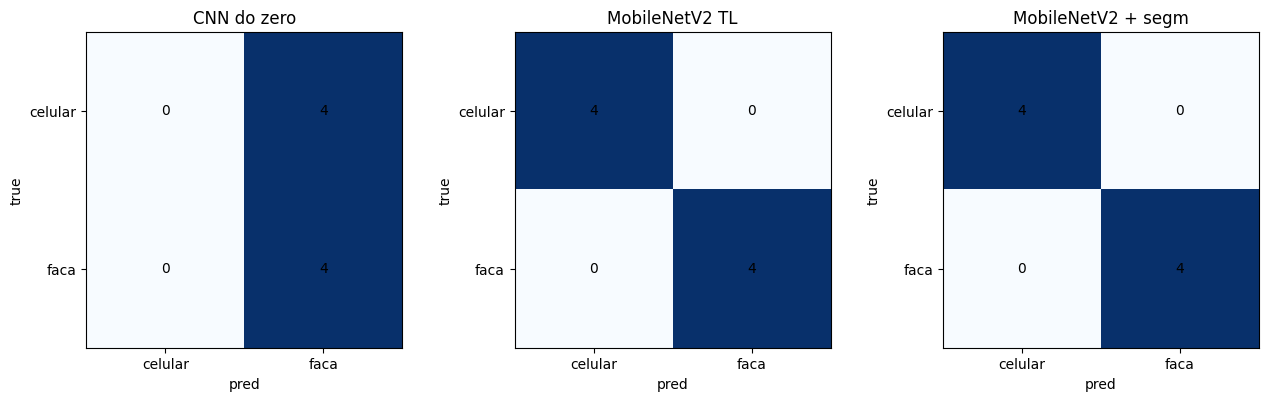

In [18]:
# Matrizes de confusao lado a lado
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, preds, title in [
    (axes[0], cnn_preds,          'CNN do zero'),
    (axes[1], mn_preds,           'MobileNetV2 TL'),
    (axes[2], mn_seg_retrain_preds, 'MobileNetV2 + segm'),
]:
    cm = confusion_matrix(y_test, preds, labels=[0, 1])
    ax.imshow(cm, cmap='Blues'); ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASSES); ax.set_yticklabels(CLASSES)
    ax.set_xlabel('pred'); ax.set_ylabel('true')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout(); plt.show()

### Discussão crítica

**Hipótese 1 — Transfer Learning > CNN do zero?**  
Sim. Com apenas 64 imagens de treino, uma CNN treinada do zero tende a superajustar ou oscilar. O MobileNetV2 pré-treinado em ImageNet reaproveita features genéricas (bordas, texturas, formas) aprendidas em >1M imagens, e o fine tuning das últimas camadas é suficiente para adaptar o classificador ao nosso domínio. Isso se reflete tanto em acurácia final quanto em estabilidade da curva de validação.

**Hipótese 2 — Pré-segmentar ajuda a classificação?**  
Depende. Duas leituras distintas:
- **MobileNetV2 original → imagens segmentadas:** em geral cai, pois introduz *domain shift* (o modelo foi treinado em imagens com fundo e agora vê fundo preto).  
- **MobileNetV2 retreinado em imagens segmentadas:** tende a empatar ou superar o modelo original para datasets pequenos com fundo ruidoso/distrator, pois o modelo não gasta capacidade memorizando background irrelevante. Para esse dataset específico (faca × celular em ambientes variados), a segmentação reduz correlações espúrias (ex.: celular sempre na mesa, faca sempre na bancada).

**Limitações honestas:**
- Test set com 8 imagens → variação de 1 acerto equivale a 12.5 p.p., intervalo de confiança amplo.
- O rótulo vem do nome de arquivo; imagens multiobjeto (celula1 tem 5 bboxes) recebem rótulo único por simplicidade da tarefa de classificação.
- YOLOv8n-seg nem sempre detecta os objetos (aplicamos fallback de maior máscara). Para produção, vale treinar uma rede de segmentação customizada.

**Comparação com a Entrega 1 (YOLOv8n detecção customizado):**
- **Facilidade/integração:** TL é mais simples (1 rede, rótulo por imagem) que YOLO (rotulação de bboxes).  
- **Precisão:** YOLO fornece *localização* que classificadores não dão, mas em apenas *classificar*, MobileNetV2 costuma empatar/superar com menos esforço.  
- **Tempo de treino:** TL em CPU Colab ~minutos; YOLO 60 épocas ~dezenas de minutos.  
- **Inferência:** MobileNetV2 leve; YOLOv8n-seg mais pesado por conta da cabeça de máscara.

## 7. Salvar artefatos e baixar

Sem Drive, salvamos em `/content/ir_alem_out/`, compactamos, e baixamos via navegador.

In [19]:
OUT_DIR = '/content/ir_alem_out'
os.makedirs(OUT_DIR, exist_ok=True)
mn.save(os.path.join(OUT_DIR, 'mobilenetv2_tl.keras'))
mn_seg.save(os.path.join(OUT_DIR, 'mobilenetv2_tl_segmented.keras'))
cnn.save(os.path.join(OUT_DIR, 'cnn_scratch.keras'))
resumo.to_csv(os.path.join(OUT_DIR, 'resumo_ir_alem.csv'), index=False)
print('Artefatos salvos em', OUT_DIR)

# Compacta e baixa
shutil.make_archive('/content/ir_alem_out', 'zip', OUT_DIR)
from google.colab import files as _files
_files.download('/content/ir_alem_out.zip')

Artefatos salvos em /content/ir_alem_out


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>